# Unit11_Example_02 | 批次反應器溫度訊號之週期性分析與頻率成分解析

本 Notebook 示範如何使用 `scipy.fft` 模組對含有**線性升溫趨勢**、**攪拌主頻與諧波**及**量測雜訊**的批次反應器溫度訊號進行頻譜分析，涵蓋去趨勢前處理、Periodogram PSD 計算、視窗函數比較、零填充技巧與自相關函數驗證。

## 目標
- 使用 `numpy.polyfit()` 去除線性趨勢，比較去趨勢前後頻譜差異
- 推導並計算 Periodogram **功率頻譜密度 (PSD)**：$S(f) = |X(f)|^2 / (f_s \cdot N)$
- 比較 **Rectangular、Hann、Hamming** 三種視窗函數的旁葉抑制特性
- 使用 `scipy.fft.next_fast_len()` 進行**零填充**，提升頻率軸密度
- 以 **Wiener-Khinchin 定理**計算自相關函數，驗證攪拌週期

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit11_Example_02'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit11'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit11
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_02
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_02\figs


---
### 1. 載入套件

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
import matplotlib
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與訊號參數

**化工背景：** 批次反應器中，攪拌槳以固定轉速（$f_1 = 8\,\mathrm{Hz} = 480\,\mathrm{rpm}$）旋轉，在溫度上升趨勢上疊加週期性溫度脈動與二次諧波：

$$
x(t) = \underbrace{T_0 + a \cdot t}_{\text{升溫趨勢}} + \underbrace{A_1 \sin(2\pi f_1 t)}_{\text{主頻}} + \underbrace{A_2 \sin(4\pi f_1 t)}_{\text{諧波}} + \underbrace{\sigma \epsilon(t)}_{\text{雜訊}}
$$

| 參數 | 符號 | 數值 | 說明 |
|------|------|------|------|
| 取樣頻率 | $f_s$ | 500 Hz | 每秒 500 次取樣 |
| 訊號長度 | $T$ | 10 s | 批次監測時間 |
| 初始溫度 | $T_0$ | 25 °C | 批次起始溫度 |
| 升溫速率 | $a$ | 5 °C/s | 線性趨勢斜率 |
| 攪拌主頻 | $f_1$ | 8 Hz | 攪拌槳轉速誘發主頻（480 rpm）|
| 主頻振幅 | $A_1$ | 2.0 °C | 攪拌引發溫度脈動振幅 |
| 二次諧波 | $2f_1$ | 16 Hz | 非線性效應諧波 |
| 諧波振幅 | $A_2$ | 0.8 °C | 二次諧波振幅 |
| 雜訊標準差 | $\sigma$ | 0.3 °C | 量測雜訊強度 |

---
### 3. 合成訊號

In [3]:
# ── 訊號合成 ──────────────────────────────────────────────
np.random.seed(42)

# 時間軸
fs = 500          # 取樣頻率 (Hz)
T  = 10.0         # 訊號時長 (s)
N  = int(fs * T)  # 樣本數
t  = np.arange(N) / fs  # 時間向量

# 訊號參數
T0    = 25.0   # 初始溫度 (°C)
a     = 5.0    # 線性趨勢斜率 (°C/s)
f1    = 8.0    # 攪拌頻率 (Hz)
A1    = 2.0    # 基頻振幅 (°C)
A2    = 0.8    # 二次諧波振幅 (°C)
sigma = 0.3    # 雜訊標準差 (°C)

# 合成各成分
trend        = T0 + a * t
signal_clean = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * 2 * f1 * t)
noise        = sigma * np.random.randn(N)
x            = trend + signal_clean + noise

# 資訊輸出
print(f"取樣頻率 fs = {fs} Hz,  樣本數 N = {N},  Δf = {fs/N:.4f} Hz")
print(f"訊號時長 T  = {T} s")
print(f"頻率解析度 Δf = {fs/N:.4f} Hz  →  f1 bin index = {int(f1/(fs/N))}")
print(f"x 範圍: [{x.min():.2f}, {x.max():.2f}] °C")
print(f"x 均值: {x.mean():.2f} °C,  標準差: {x.std():.2f} °C")

取樣頻率 fs = 500 Hz,  樣本數 N = 5000,  Δf = 0.1000 Hz
訊號時長 T  = 10.0 s
頻率解析度 Δf = 0.1000 Hz  →  f1 bin index = 80
x 範圍: [22.68, 77.17] °C
x 均值: 50.00 °C,  標準差: 14.49 °C


---
### 4. 去趨勢前處理 (Detrending)

In [4]:
# ── 去趨勢：polyfit 一次多項式擬合 ────────────────────────
coeffs     = np.polyfit(t, x, 1)          # 擬合線性趨勢
trend_fit  = np.polyval(coeffs, t)        # 估計趨勢
x_detrend  = x - trend_fit               # 去趨勢後訊號

# 去均值 (用於頻譜比較，避免 DC 成分)
x_demean   = x - x.mean()

print(f"擬合趨勢斜率: {coeffs[0]:.4f} °C/s  (真實值: {a} °C/s)")
print(f"擬合截距:     {coeffs[1]:.4f} °C    (真實值: {T0} °C)")
print(f"去趨勢後均值: {x_detrend.mean():.6f} °C  (接近 0)")
print(f"去趨勢後標準差: {x_detrend.std():.4f} °C")

擬合趨勢斜率: 4.9913 °C/s  (真實值: 5.0 °C/s)
擬合截距:     25.0450 °C    (真實值: 25.0 °C)
去趨勢後均值: -0.000000 °C  (接近 0)
去趨勢後標準差: 1.5514 °C


---
### 5. 去趨勢前後頻譜比較

In [5]:
# ── rfft：去趨勢前後振幅頻譜計算 ──────────────────────────
from scipy.fft import rfft, rfftfreq

freqs  = rfftfreq(N, d=1/fs)          # 頻率軸 (Hz)

# 去均值後 rfft (代表「未去趨勢，但移除DC」)
X_demean  = rfft(x_demean)
amp_demean = (2 / N) * np.abs(X_demean)

# 去趨勢後 rfft
X_detrend  = rfft(x_detrend)
amp_detrend = (2 / N) * np.abs(X_detrend)

# 找主要峰值
fr_f1  = int(f1  / (fs / N))   # bin index for f1  = 8 Hz
fr_2f1 = int(2*f1 / (fs / N))  # bin index for 2f1 = 16 Hz

print(f"  [去均值]  f1={freqs[fr_f1]:.1f}Hz → A={amp_demean[fr_f1]:.4f} °C  "
      f"| 2f1={freqs[fr_2f1]:.1f}Hz → A={amp_demean[fr_2f1]:.4f} °C")
print(f"  [去趨勢]  f1={freqs[fr_f1]:.1f}Hz → A={amp_detrend[fr_f1]:.4f} °C  "
      f"| 2f1={freqs[fr_2f1]:.1f}Hz → A={amp_detrend[fr_2f1]:.4f} °C")
print(f"\n  真實振幅 — A1={A1} °C  (f1={f1} Hz),  A2={A2} °C  (2f1={2*f1} Hz)")

  [去均值]  f1=8.0Hz → A=1.8022 °C  | 2f1=16.0Hz → A=0.6962 °C
  [去趨勢]  f1=8.0Hz → A=2.0006 °C  | 2f1=16.0Hz → A=0.7951 °C

  真實振幅 — A1=2.0 °C  (f1=8.0 Hz),  A2=0.8 °C  (2f1=16.0 Hz)


---
### 6. Periodogram PSD 計算與 Parseval 定理驗證

In [6]:
# ── Periodogram PSD (矩形窗) ─────────────────────────────
df = fs / N   # 頻率解析度

# PSD: 單側 (one-sided) periodogram
psd = (np.abs(X_detrend)**2) / (N * fs)   # V²/Hz
psd[1:-1] *= 2                            # 單側 × 2 (除 DC 與 Nyquist)

# 理論峰值 PSD = A²/(2·df) [V²/Hz]
psd_theory_f1  = A1**2 / (2 * df)
psd_theory_2f1 = A2**2 / (2 * df)

print(f"PSD at f1  = {freqs[fr_f1]:.1f} Hz:  {psd[fr_f1]:.4f} °C²/Hz  "
      f"(Theory: {psd_theory_f1:.4f})")
print(f"PSD at 2f1 = {freqs[fr_2f1]:.1f} Hz:  {psd[fr_2f1]:.4f} °C²/Hz  "
      f"(Theory: {psd_theory_2f1:.4f})")

# Parseval 定理驗證
power_time  = np.mean(x_detrend**2)
power_freq  = np.sum(psd) * df          # 積分 PSD
print(f"\nParseval 定理驗證:")
print(f"  時域功率 = {power_time:.6f} °C²")
print(f"  頻域功率 = {power_freq:.6f} °C²")
print(f"  相對誤差 = {abs(power_time - power_freq)/power_time*100:.4f} %")

PSD at f1  = 8.0 Hz:  20.0116 °C²/Hz  (Theory: 20.0000)
PSD at 2f1 = 16.0 Hz:  3.1613 °C²/Hz  (Theory: 3.2000)

Parseval 定理驗證:
  時域功率 = 2.406819 °C²
  頻域功率 = 2.406819 °C²
  相對誤差 = 0.0000 %


---
### 7. 視窗函數比較 (Rectangular, Hann, Hamming)

In [7]:
# ── 三種視窗函數 PSD 比較 ─────────────────────────────────
windows = {
    "Rectangular": np.ones(N),
    "Hann"       : np.hanning(N),
    "Hamming"    : np.hamming(N),
}

psd_windows = {}
for name, win in windows.items():
    win_norm = np.sum(win**2)                    # 歸一化因子
    X_win    = rfft(x_detrend * win)
    P        = (np.abs(X_win)**2) / (win_norm * fs)
    P[1:-1] *= 2
    psd_windows[name] = P

# 輸出三種窗在 f1 / 2f1 的 PSD 值
header = f"{'Window':<12}  {'PSD@8Hz':>12}  {'PSD@16Hz':>12}"
print(header)
print("-" * len(header))
for name, P in psd_windows.items():
    print(f"{name:<12}  {P[fr_f1]:>12.4f}  {P[fr_2f1]:>12.4f}")

Window             PSD@8Hz      PSD@16Hz
----------------------------------------
Rectangular        20.0116        3.1613
Hann               13.3986        2.1173
Hamming            14.7382        2.3289


---
### 8. 零填充 (Zero Padding) 與 `next_fast_len`

In [8]:
# ── 零填充 ───────────────────────────────────────────────
from scipy.fft import next_fast_len

N_zp   = next_fast_len(2 * N)          # 下一個高效 FFT 長度 (≥ 2N)
freqs_zp = rfftfreq(N_zp, d=1/fs)

X_zp  = rfft(x_detrend, n=N_zp)
psd_zp = (np.abs(X_zp)**2) / (N * fs)  # 注意分母仍用原始 N
psd_zp[1:-1] *= 2

print(f"原始長度  N    = {N}")
print(f"零填充後 N_zp = {N_zp}  (next_fast_len ≥ 2N)")
print(f"頻率解析度 — 原始: {fs/N:.4f} Hz,  零填充後: {fs/N_zp:.6f} Hz")

# 比較 f1 峰值細緻程度 (± 3 個 bin)
idx_f1_zp  = np.argmin(np.abs(freqs_zp - f1))
print(f"\n零填充後 f1 附近頻率:")
for di in range(-2, 3):
    idx = idx_f1_zp + di
    if 0 <= idx < len(freqs_zp):
        print(f"  {freqs_zp[idx]:.4f} Hz → PSD={psd_zp[idx]:.4f} °C²/Hz")

原始長度  N    = 5000
零填充後 N_zp = 10000  (next_fast_len ≥ 2N)
頻率解析度 — 原始: 0.1000 Hz,  零填充後: 0.050000 Hz

零填充後 f1 附近頻率:
  7.9000 Hz → PSD=0.0004 °C²/Hz
  7.9500 Hz → PSD=8.3198 °C²/Hz
  8.0000 Hz → PSD=20.0116 °C²/Hz
  8.0500 Hz → PSD=7.9666 °C²/Hz
  8.1000 Hz → PSD=0.0000 °C²/Hz


---
### 9. 自相關函數與 Wiener-Khinchin 定理驗證

In [12]:
# ── Wiener-Khinchin 定理：ACF ↔ PSD ──────────────────────
from scipy.fft import fft, ifft
from scipy.signal import find_peaks

# Zero-pad to avoid circular correlation (length ≥ 2N-1)
N_acf   = next_fast_len(2 * N - 1)
X_full  = fft(x_detrend, n=N_acf)

# ACF via IFFT of power spectrum
acf_full = np.real(ifft(np.abs(X_full)**2)) / N
acf      = acf_full[:N]                      # 取正延遲部分
acf_norm = acf / acf[0]                      # 歸一化 (R[0]=1)
lags     = np.arange(N) / fs                 # 延遲時間軸 (s)

# Wiener-Khinchin 驗證：ACF 的 FFT 應還原 PSD
# S(f) = DFT(R[m]) / fs  (single-sided: x2 for non-DC/Nyquist)
psd_wk       = np.real(fft(acf_full))[:N_acf//2+1] / fs
psd_wk[1:-1] *= 2
freqs_wk     = rfftfreq(N_acf, d=1/fs)      # 頻率軸：0 → 250 Hz

# 找 ACF 正延遲部分的主要峰值 → 估計週期
peaks_acf, _  = find_peaks(acf_norm[:int(0.5*fs)], height=0.05, distance=20)
if len(peaks_acf) > 0:
    period_est = lags[peaks_acf[0]]
    print(f"ACF 第一個峰值延遲: {period_est:.4f} s → 估計頻率: {1/period_est:.2f} Hz  (真實: {f1} Hz)")
else:
    print("ACF 未找到顯著峰值")

print(f"\nACF[0]       = {acf[0]:.4f} °C²  (= 訊號方差)")
print(f"訊號方差     = {np.var(x_detrend):.4f} °C²")

# Wiener-Khinchin 正確性驗證
idx_f1_wk = np.argmin(np.abs(freqs_wk - f1))
print(f"\nWiener-Khinchin 驗證 — PSD at f1={f1} Hz:")
print(f"  Periodogram PSD = {psd[fr_f1]:.4f} °C²/Hz")
print(f"  WK PSD          = {psd_wk[idx_f1_wk]:.4f} °C²/Hz")

ACF 第一個峰值延遲: 0.1240 s → 估計頻率: 8.06 Hz  (真實: 8.0 Hz)

ACF[0]       = 2.4068 °C²  (= 訊號方差)
訊號方差     = 2.4068 °C²

Wiener-Khinchin 驗證 — PSD at f1=8.0 Hz:
  Periodogram PSD = 20.0116 °C²/Hz
  WK PSD          = 20.0116 °C²/Hz


---
### 10. 繪製所有圖形並儲存

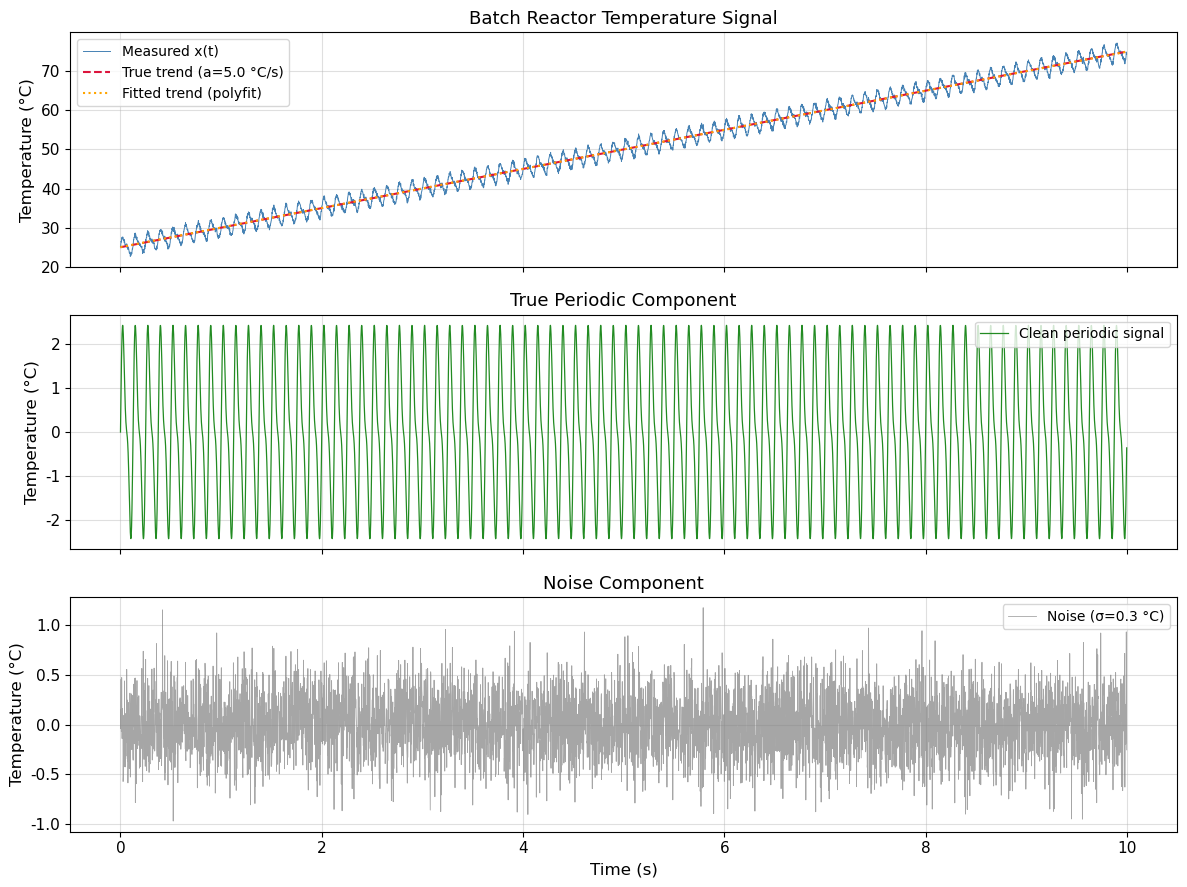

fig01 saved.


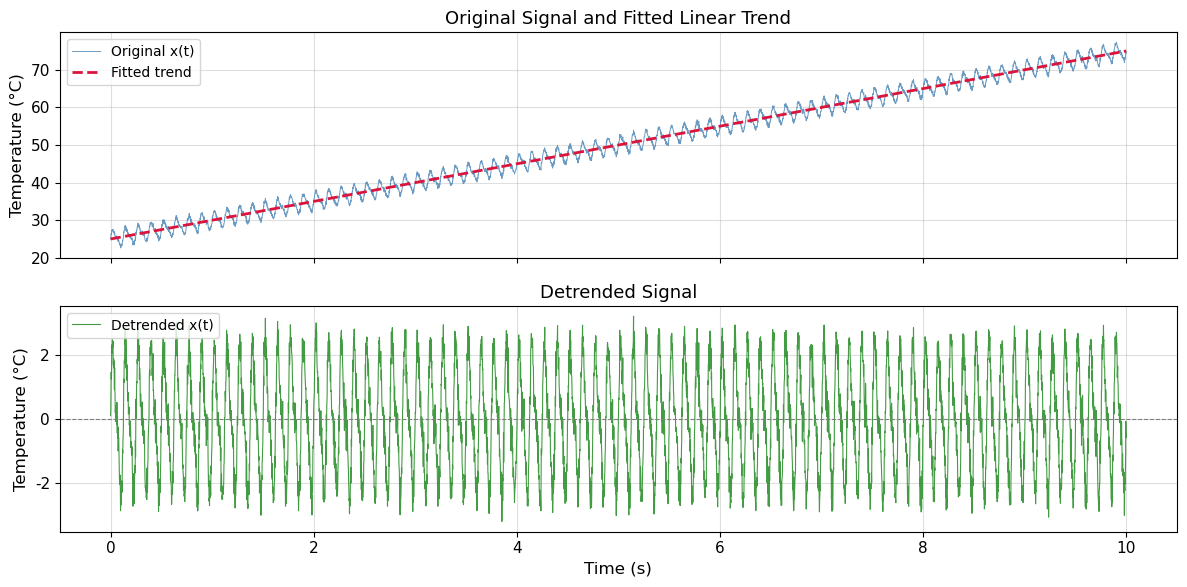

fig02 saved.


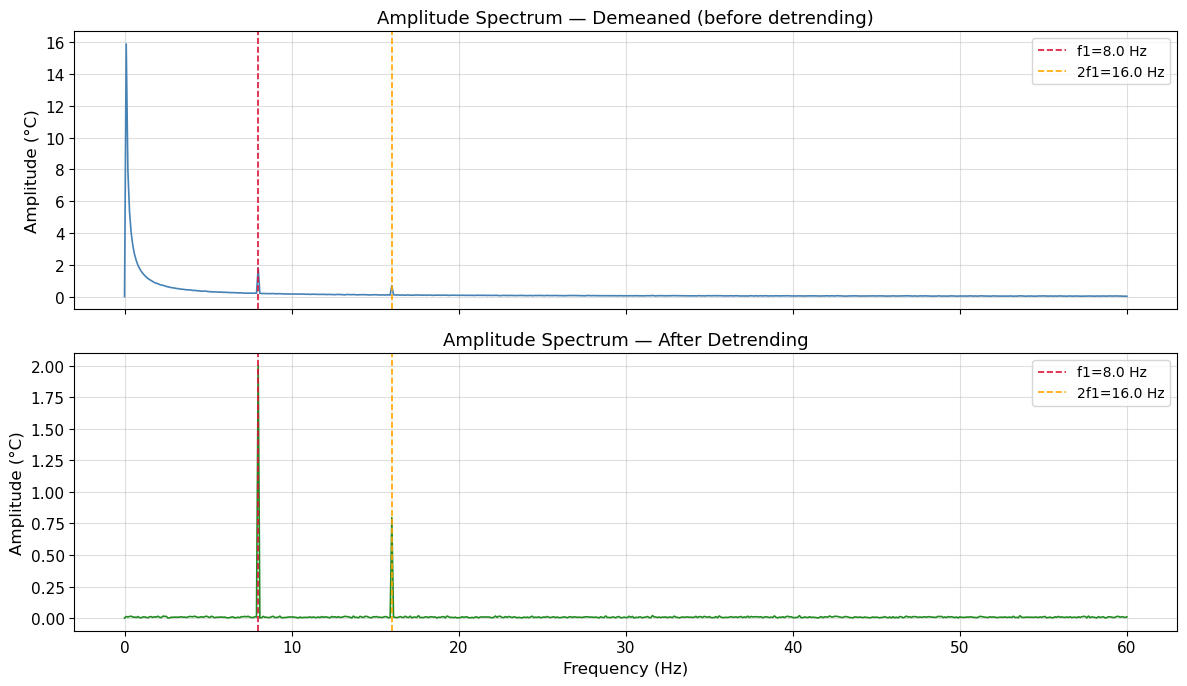

fig03 saved.


In [10]:
# ═══════════════════════════════════════════════════════════
# fig01: 原始批次反應器溫度訊號
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t, x,       lw=0.7, color='steelblue', label='Measured x(t)')
axes[0].plot(t, trend,   lw=1.5, color='crimson',   label=f'True trend (a={a} °C/s)', ls='--')
axes[0].plot(t, trend_fit, lw=1.5, color='orange',  label='Fitted trend (polyfit)', ls=':')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Batch Reactor Temperature Signal')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t, signal_clean, lw=0.9, color='forestgreen', label='Clean periodic signal')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('True Periodic Component')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

axes[2].plot(t, noise, lw=0.6, color='gray', alpha=0.7, label=f'Noise (σ={sigma} °C)')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Noise Component')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig01_raw_signal.png', dpi=150)
plt.show()
print("fig01 saved.")

# ═══════════════════════════════════════════════════════════
# fig02: 去趨勢比較
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, x, lw=0.7, color='steelblue', alpha=0.8, label='Original x(t)')
axes[0].plot(t, trend_fit, lw=2, color='crimson', ls='--', label='Fitted trend')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Original Signal and Fitted Linear Trend')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(t, x_detrend, lw=0.8, color='forestgreen', alpha=0.85, label='Detrended x(t)')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Detrended Signal')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig02_detrend_comparison.png', dpi=150)
plt.show()
print("fig02 saved.")

# ═══════════════════════════════════════════════════════════
# fig03: 去趨勢前後頻譜比較
# ═══════════════════════════════════════════════════════════
fmax_plot = 60   # 顯示頻率上限

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

mask = freqs <= fmax_plot

axes[0].plot(freqs[mask], amp_demean[mask], lw=1.2, color='steelblue')
axes[0].axvline(f1,   color='crimson',   ls='--', lw=1.2, label=f'f1={f1} Hz')
axes[0].axvline(2*f1, color='orange',    ls='--', lw=1.2, label=f'2f1={2*f1} Hz')
axes[0].set_ylabel('Amplitude (°C)')
axes[0].set_title('Amplitude Spectrum — Demeaned (before detrending)')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(freqs[mask], amp_detrend[mask], lw=1.2, color='forestgreen')
axes[1].axvline(f1,   color='crimson',   ls='--', lw=1.2, label=f'f1={f1} Hz')
axes[1].axvline(2*f1, color='orange',    ls='--', lw=1.2, label=f'2f1={2*f1} Hz')
axes[1].set_ylabel('Amplitude (°C)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_title('Amplitude Spectrum — After Detrending')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig03_spectrum_detrend.png', dpi=150)
plt.show()
print("fig03 saved.")

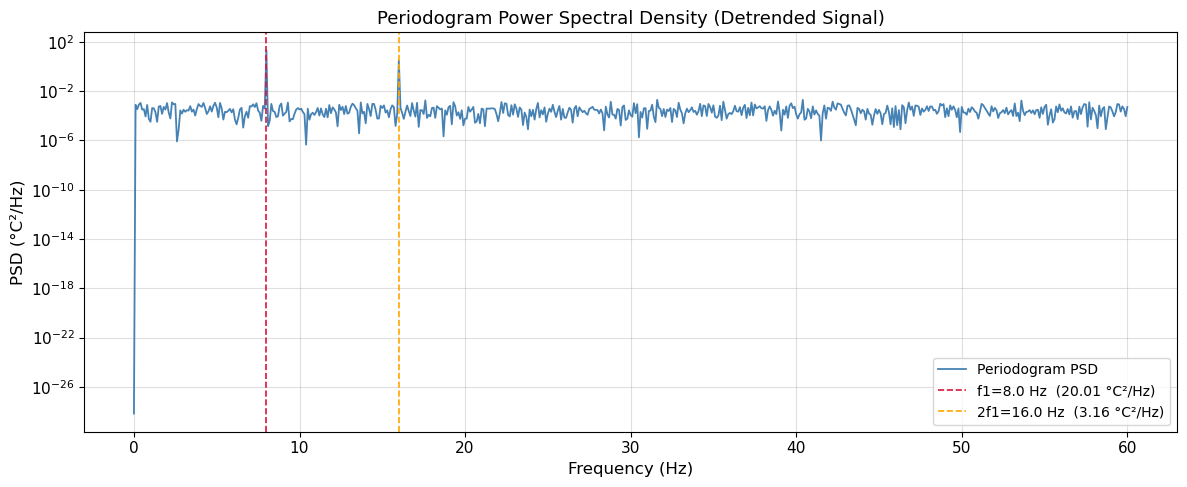

fig04 saved.


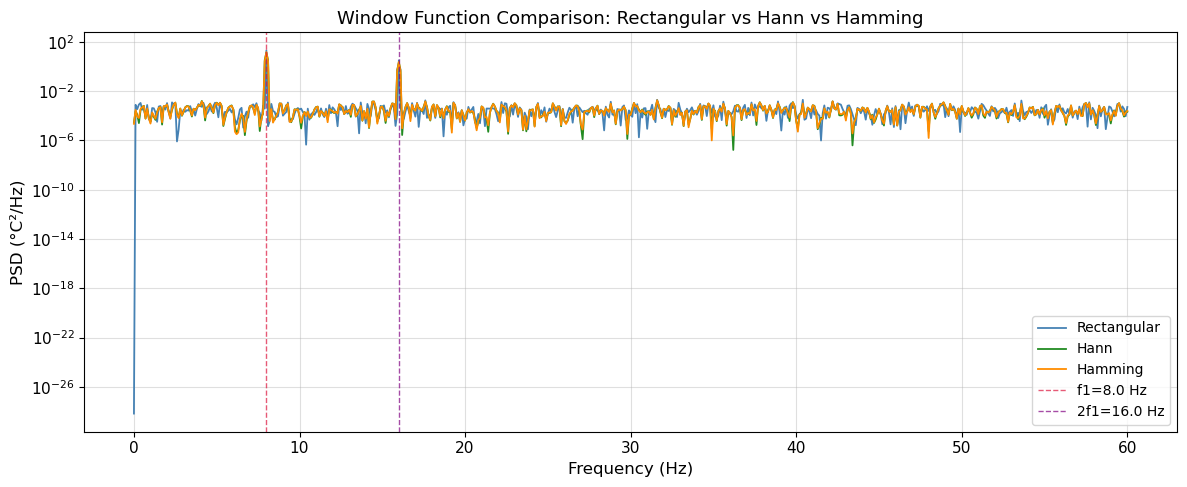

fig05 saved.


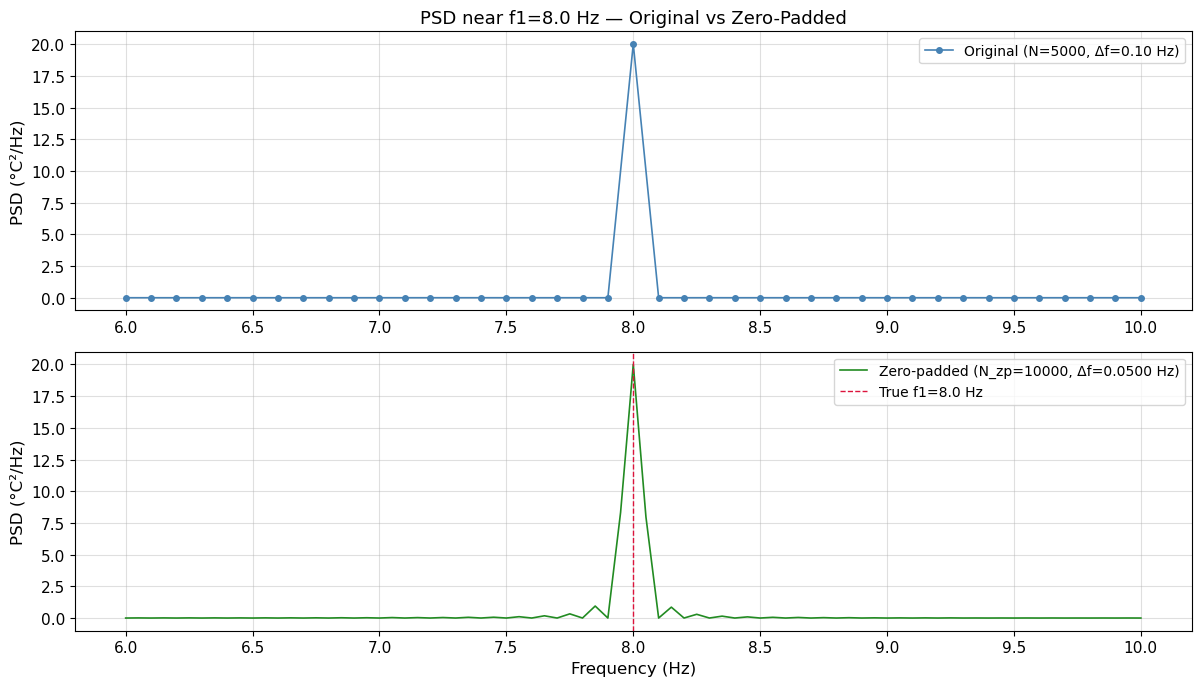

fig06 saved.


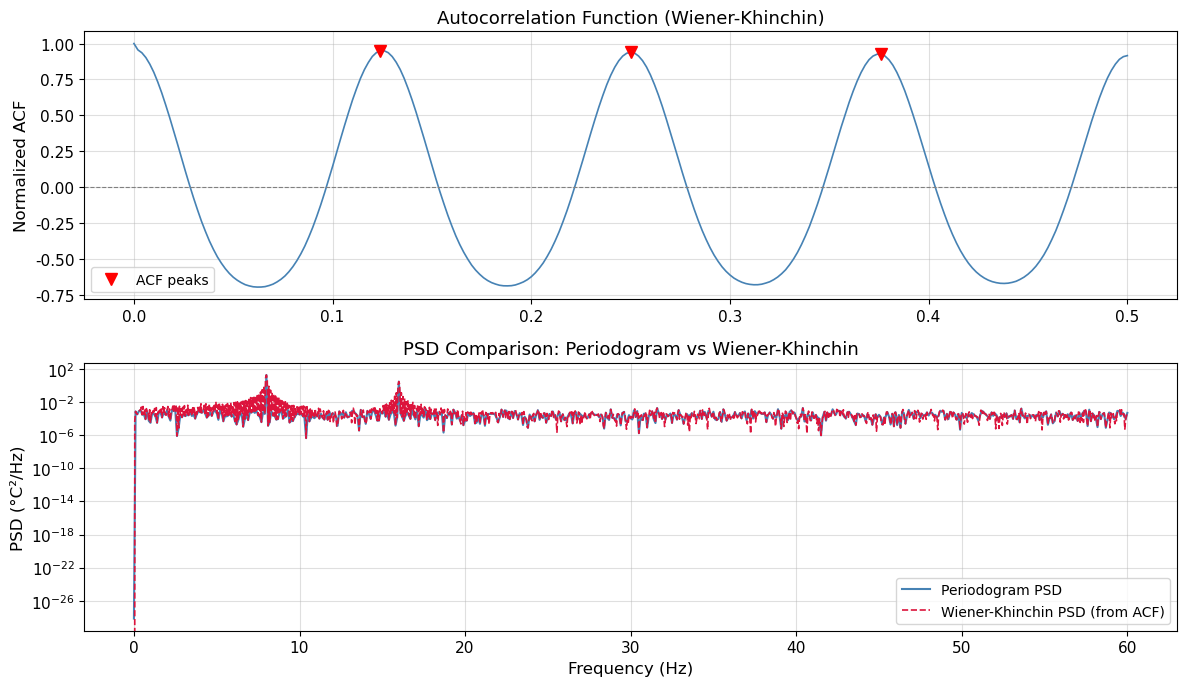

fig07 saved.

=== 所有圖形已儲存至: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_02\figs ===


In [13]:
# ═══════════════════════════════════════════════════════════
# fig04: Periodogram PSD
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))

ax.semilogy(freqs[mask], psd[mask], lw=1.3, color='steelblue', label='Periodogram PSD')
ax.axvline(f1,   color='crimson', ls='--', lw=1.2, label=f'f1={f1} Hz  ({psd[fr_f1]:.2f} °C²/Hz)')
ax.axvline(2*f1, color='orange',  ls='--', lw=1.2, label=f'2f1={2*f1} Hz  ({psd[fr_2f1]:.2f} °C²/Hz)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (°C²/Hz)')
ax.set_title('Periodogram Power Spectral Density (Detrended Signal)')
ax.legend()
ax.grid(True, alpha=0.4, which='both')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig04_psd_periodogram.png', dpi=150)
plt.show()
print("fig04 saved.")

# ═══════════════════════════════════════════════════════════
# fig05: 三種視窗函數 PSD 比較
# ═══════════════════════════════════════════════════════════
colors = {'Rectangular': 'steelblue', 'Hann': 'forestgreen', 'Hamming': 'darkorange'}

fig, ax = plt.subplots(figsize=(12, 5))
for name, P in psd_windows.items():
    ax.semilogy(freqs[mask], P[mask], lw=1.3, color=colors[name], label=name)
ax.axvline(f1,   color='crimson', ls='--', lw=1, alpha=0.7, label=f'f1={f1} Hz')
ax.axvline(2*f1, color='purple',  ls='--', lw=1, alpha=0.7, label=f'2f1={2*f1} Hz')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (°C²/Hz)')
ax.set_title('Window Function Comparison: Rectangular vs Hann vs Hamming')
ax.legend()
ax.grid(True, alpha=0.4, which='both')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig05_window_psd_comparison.png', dpi=150)
plt.show()
print("fig05 saved.")

# ═══════════════════════════════════════════════════════════
# fig06: 零填充效果
# ═══════════════════════════════════════════════════════════
frange = (6, 10)   # 放大 f1 附近
mask_orig = (freqs    >= frange[0]) & (freqs    <= frange[1])
mask_zp   = (freqs_zp >= frange[0]) & (freqs_zp <= frange[1])

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(freqs[mask_orig],    psd[mask_orig],    'o-', ms=4, lw=1.2,
             color='steelblue', label=f'Original (N={N}, Δf={fs/N:.2f} Hz)')
axes[0].set_ylabel('PSD (°C²/Hz)')
axes[0].set_title(f'PSD near f1={f1} Hz — Original vs Zero-Padded')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(freqs_zp[mask_zp], psd_zp[mask_zp],  '-', lw=1.2,
             color='forestgreen', label=f'Zero-padded (N_zp={N_zp}, Δf={fs/N_zp:.4f} Hz)')
axes[1].axvline(f1, color='crimson', ls='--', lw=1, label=f'True f1={f1} Hz')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD (°C²/Hz)')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig06_zero_padding.png', dpi=150)
plt.show()
print("fig06 saved.")

# ═══════════════════════════════════════════════════════════
# fig07: 自相關函數 ACF
# ═══════════════════════════════════════════════════════════
lag_max = 0.5    # 顯示最大延遲 (s)
mask_lag = lags <= lag_max

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(lags[mask_lag], acf_norm[mask_lag], lw=1.2, color='steelblue')
if len(peaks_acf) > 0:
    pk_mask = peaks_acf[peaks_acf < int(lag_max*fs)]
    axes[0].plot(lags[pk_mask], acf_norm[pk_mask], 'rv', ms=8, label='ACF peaks')
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel('Normalized ACF')
axes[0].set_title('Autocorrelation Function (Wiener-Khinchin)')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Wiener-Khinchin 驗證：比較 Periodogram PSD 與 ACF-derived PSD
mask_wk = freqs_wk <= fmax_plot
axes[1].semilogy(freqs[mask],    psd[mask],               lw=1.5, color='steelblue',
                 label='Periodogram PSD')
axes[1].semilogy(freqs_wk[mask_wk], psd_wk[mask_wk],     lw=1.2, color='crimson',
                 ls='--', label='Wiener-Khinchin PSD (from ACF)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD (°C²/Hz)')
axes[1].set_title('PSD Comparison: Periodogram vs Wiener-Khinchin')
axes[1].legend()
axes[1].grid(True, alpha=0.4, which='both')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig07_autocorrelation.png', dpi=150)
plt.show()
print("fig07 saved.")

print("\n=== 所有圖形已儲存至:", FIG_DIR, "===")